In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load 500K rows for exploration — representative sample
df = pd.read_csv('../data/raw/paysim.csv')
print(f"Full dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 3 rows:")
df.head(3)

Full dataset shape: (6362620, 11)
Memory usage: 1.42 GB

Column names: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

First 3 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0


=== CLASS DISTRIBUTION ===
Legitimate:  6,354,407
Fraudulent:      8,213
Fraud rate: 0.1291%

=== IMPLICATION FOR MODEL DESIGN ===
A model predicting 'not fraud' for every transaction:
  Accuracy: 99.8709% — MISLEADING
  Fraud recall: 0% — USELESS

This is why we use AUCPR, not accuracy, as the training metric.
This is why we use SMOTE on training data to balance classes.
This is why recall is more important than precision for fraud.
This is why the test set must keep the real distribution.


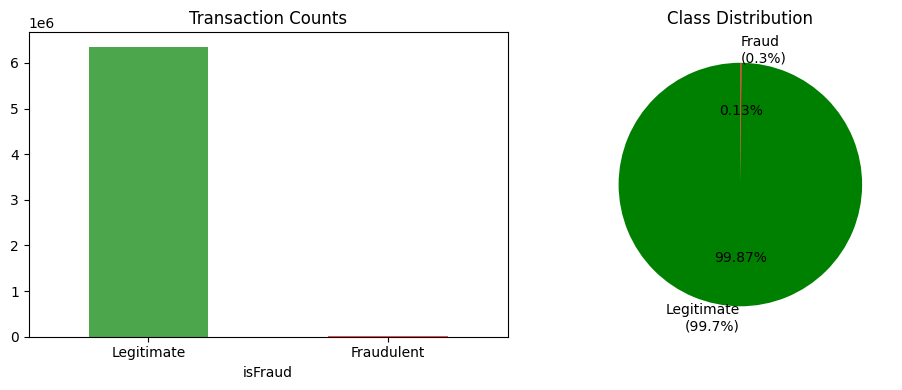

In [2]:
counts = df['isFraud'].value_counts()
fraud_rate = counts[1] / len(df) * 100

print("=== CLASS DISTRIBUTION ===")
print(f"Legitimate: {counts[0]:>10,}")
print(f"Fraudulent: {counts[1]:>10,}")
print(f"Fraud rate: {fraud_rate:.4f}%")
print()
print("=== IMPLICATION FOR MODEL DESIGN ===")
print(f"A model predicting 'not fraud' for every transaction:")
print(f"  Accuracy: {100 - fraud_rate:.4f}% — MISLEADING")
print(f"  Fraud recall: 0% — USELESS")
print()
print("This is why we use AUCPR, not accuracy, as the training metric.")
print("This is why we use SMOTE on training data to balance classes.")
print("This is why recall is more important than precision for fraud.")
print("This is why the test set must keep the real distribution.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind='bar', ax=ax1, color=['green', 'red'], alpha=0.7)
ax1.set_title('Transaction Counts')
ax1.set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

# Pie chart showing how small fraud actually is
ax2.pie([counts[0], counts[1]],
        labels=['Legitimate\n(99.7%)', 'Fraud\n(0.3%)'],
        colors=['green', 'red'],
        autopct='%1.2f%%',
        startangle=90)
ax2.set_title('Class Distribution')
plt.tight_layout()
plt.show()

In [3]:
# This finding determines the type guard in inference
type_analysis = df.groupby('type').agg(
    total=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum'),
    fraud_rate=('isFraud', lambda x: f"{x.mean()*100:.4f}%")
).sort_values('fraud_count', ascending=False)

print("=== FRAUD BY TRANSACTION TYPE ===")
print(type_analysis.to_string())
print()
print("=== CRITICAL INSIGHT ===")
print("Fraud ONLY occurs in TRANSFER and CASH_OUT transactions.")
print("PAYMENT, CASH_IN, and DEBIT have ZERO fraud in 6.3M records.")
print()
print("Design decisions this drives:")
print("1. Filter training data to TRANSFER and CASH_OUT only")
print("2. Add type guard in detection_service.py:")
print("   - PAYMENT/CASH_IN/DEBIT → auto-approve without ML scoring")
print("   - TRANSFER/CASH_OUT → run full ML pipeline")
print("3. Encode is_transfer and is_cashout as binary features")
print("4. Model output for PAYMENT would be unreliable (out-of-distribution)")

=== FRAUD BY TRANSACTION TYPE ===
            total  fraud_count fraud_rate
type                                     
CASH_OUT  2237500         4116    0.1840%
TRANSFER   532909         4097    0.7688%
CASH_IN   1399284            0    0.0000%
DEBIT       41432            0    0.0000%
PAYMENT   2151495            0    0.0000%

=== CRITICAL INSIGHT ===
Fraud ONLY occurs in TRANSFER and CASH_OUT transactions.
PAYMENT, CASH_IN, and DEBIT have ZERO fraud in 6.3M records.

Design decisions this drives:
1. Filter training data to TRANSFER and CASH_OUT only
2. Add type guard in detection_service.py:
   - PAYMENT/CASH_IN/DEBIT → auto-approve without ML scoring
   - TRANSFER/CASH_OUT → run full ML pipeline
3. Encode is_transfer and is_cashout as binary features
4. Model output for PAYMENT would be unreliable (out-of-distribution)


In [4]:
transfer_fraud = df[(df['type'] == 'TRANSFER') & (df['isFraud'] == 1)]
transfer_legit = df[(df['type'] == 'TRANSFER') & (df['isFraud'] == 0)]

print("=== FRAUDULENT TRANSFERS — BALANCE PATTERNS ===")
fraud_sample = transfer_fraud[
    ['amount', 'oldbalanceOrg', 'newbalanceOrig',
     'oldbalanceDest', 'newbalanceDest']
].head(8)
print(fraud_sample.to_string())

print()
print("=== LEGITIMATE TRANSFERS — BALANCE PATTERNS ===")
legit_sample = transfer_legit[
    ['amount', 'oldbalanceOrg', 'newbalanceOrig',
     'oldbalanceDest', 'newbalanceDest']
].head(8)
print(legit_sample.to_string())

print()
print("=== PATTERNS OBSERVED ===")
print()

# Pattern 1: Account draining
drain_rate = (transfer_fraud['newbalanceOrig'] == 0).mean()
print(f"1. Account drain (newbalanceOrig = 0):")
print(f"   Fraud: {drain_rate*100:.1f}% of cases")
print(f"   → Feature: orig_balance_zeroed")

# Pattern 2: Zero destination
zero_dest_before = (transfer_fraud['oldbalanceDest'] == 0).mean()
print(f"2. Mule account (oldbalanceDest = 0):")
print(f"   Fraud: {zero_dest_before*100:.1f}% of cases")
print(f"   → Feature: dest_balance_zero_before")

# Pattern 3: Destination zero after
zero_dest_after = (transfer_fraud['newbalanceDest'] == 0).mean()
print(f"3. Immediate forwarding (newbalanceDest = 0):")
print(f"   Fraud: {zero_dest_after*100:.1f}% of cases")
print(f"   → Feature: dest_balance_zero_after")

print()
print("These three flags will be highly predictive features.")
print("They capture the signature of account takeover fraud.")

=== FRAUDULENT TRANSFERS — BALANCE PATTERNS ===
          amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest
2         181.00         181.00             0.0             0.0             0.0
251      2806.00        2806.00             0.0             0.0             0.0
680     20128.00       20128.00             0.0             0.0             0.0
969   1277212.77     1277212.77             0.0             0.0             0.0
1115    35063.63       35063.63             0.0             0.0             0.0
1869    25071.46       25071.46             0.0             0.0             0.0
2301   235238.66      235238.66             0.0             0.0             0.0
3059  1096187.24     1096187.24             0.0             0.0             0.0

=== LEGITIMATE TRANSFERS — BALANCE PATTERNS ===
       amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest
19  215310.30         705.00             0.0        22425.00            0.00
24  311685.89       10835.00 

=== AMOUNT STATISTICS ===

Legitimate TRANSFER:
  Mean:   ₦       906,229
  Median: ₦       486,522
  Max:    ₦    92,445,517

Fraudulent TRANSFER:
  Mean:   ₦     1,480,892
  Median: ₦       445,706
  Max:    ₦    10,000,000

Fraud cases where amount > 95% of balance: 96.5%
→ Feature: amount_ratio_orig = amount / (oldbalanceOrg + 1)
  A ratio near 1.0 = account drain. Highly predictive.


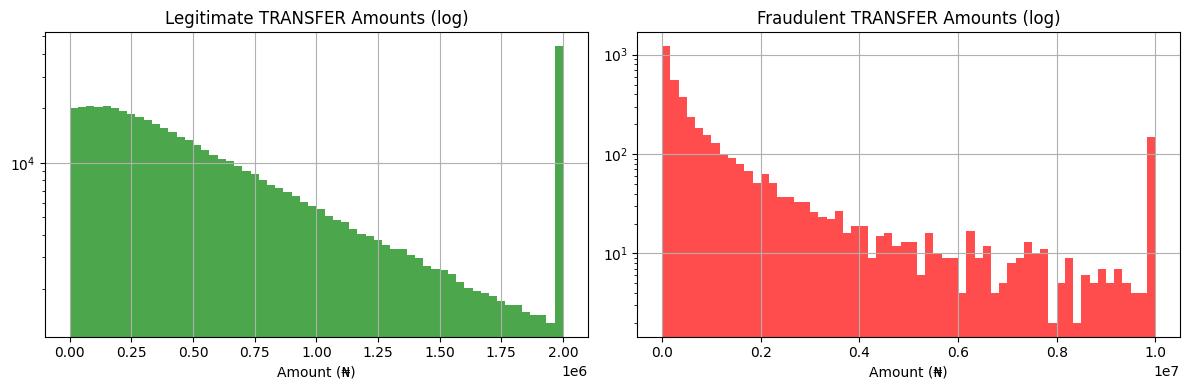

In [5]:
print("=== AMOUNT STATISTICS ===")
print(f"\nLegitimate TRANSFER:")
print(f"  Mean:   ₦{transfer_legit['amount'].mean():>14,.0f}")
print(f"  Median: ₦{transfer_legit['amount'].median():>14,.0f}")
print(f"  Max:    ₦{transfer_legit['amount'].max():>14,.0f}")

print(f"\nFraudulent TRANSFER:")
print(f"  Mean:   ₦{transfer_fraud['amount'].mean():>14,.0f}")
print(f"  Median: ₦{transfer_fraud['amount'].median():>14,.0f}")
print(f"  Max:    ₦{transfer_fraud['amount'].max():>14,.0f}")

# Check how often fraud = full account balance
amount_ratio_fraud = (
    transfer_fraud['amount'] / (transfer_fraud['oldbalanceOrg'] + 1)
)
full_drain = (amount_ratio_fraud > 0.95).mean()
print(f"\nFraud cases where amount > 95% of balance: {full_drain*100:.1f}%")
print("→ Feature: amount_ratio_orig = amount / (oldbalanceOrg + 1)")
print("  A ratio near 1.0 = account drain. Highly predictive.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
transfer_legit['amount'].clip(upper=2e6).hist(
    bins=60, ax=axes[0], color='green', alpha=0.7, log=True
)
axes[0].set_title('Legitimate TRANSFER Amounts (log)')
axes[0].set_xlabel('Amount (₦)')

transfer_fraud['amount'].hist(
    bins=60, ax=axes[1], color='red', alpha=0.7, log=True
)
axes[1].set_title('Fraudulent TRANSFER Amounts (log)')
axes[1].set_xlabel('Amount (₦)')
plt.tight_layout()
plt.show()

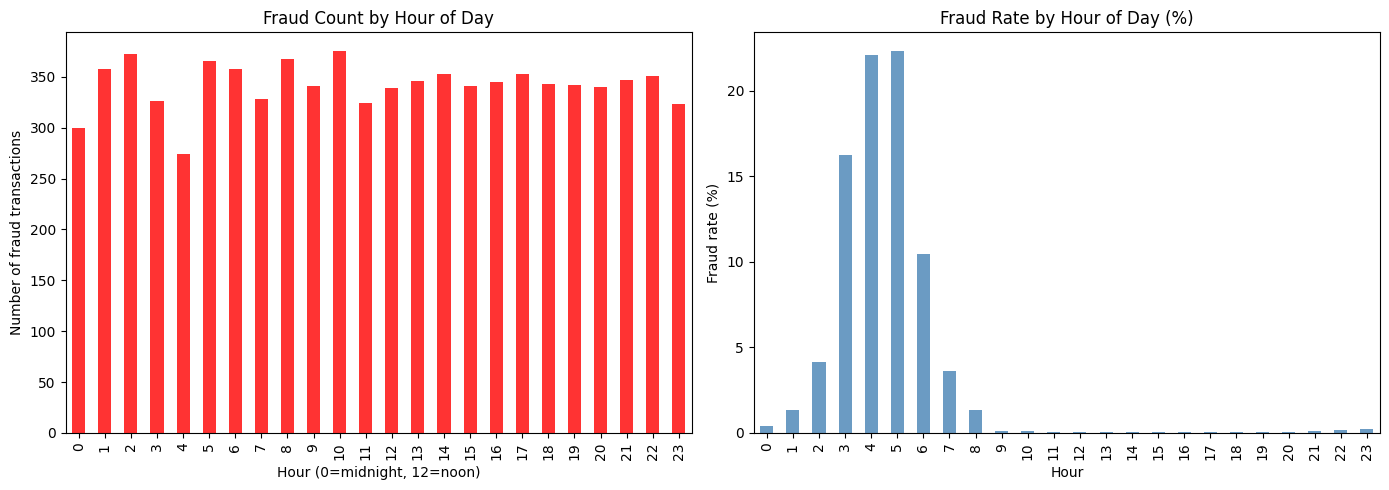

=== TIME FEATURE DESIGN ===

Raw 'step' column: integer from 1 to 744 (hours across 30 days)
  → Monotonically increasing, no repeating pattern
  → A tree split on step=347 is meaningless

hour_of_day = step % 24: integer from 0 to 23, repeating daily
  → Captures 'what time of day?' which fraud patterns follow
  → step=347 and step=371 both become hour=11 (11am)
  → The model treats them correctly as similar


In [6]:
df['hour_of_day'] = df['step'] % 24

fraud_by_hour = df[df['isFraud']==1].groupby('hour_of_day').size()
legit_by_hour = df[df['isFraud']==0].groupby('hour_of_day').size()
fraud_rate_by_hour = (
    df.groupby('hour_of_day')['isFraud'].mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_by_hour.plot(kind='bar', ax=axes[0], color='red', alpha=0.8)
axes[0].set_title('Fraud Count by Hour of Day')
axes[0].set_xlabel('Hour (0=midnight, 12=noon)')
axes[0].set_ylabel('Number of fraud transactions')

fraud_rate_by_hour.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Fraud Rate by Hour of Day (%)')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud rate (%)')

plt.tight_layout()
plt.show()

print("=== TIME FEATURE DESIGN ===")
print()
print("Raw 'step' column: integer from 1 to 744 (hours across 30 days)")
print("  → Monotonically increasing, no repeating pattern")
print("  → A tree split on step=347 is meaningless")
print()
print("hour_of_day = step % 24: integer from 0 to 23, repeating daily")
print("  → Captures 'what time of day?' which fraud patterns follow")
print("  → step=347 and step=371 both become hour=11 (11am)")
print("  → The model treats them correctly as similar")

In [7]:
print("=" * 60)
print(" FEATURE ENGINEERING DESIGN — FINAL DECISIONS")
print("=" * 60)

features = [
    ("amount",                "Direct",    "Transaction amount"),
    ("oldbalanceOrg",         "Direct",    "Sender balance before"),
    ("newbalanceOrig",        "Direct",    "Sender balance after"),
    ("oldbalanceDest",        "Direct",    "Recipient balance before"),
    ("newbalanceDest",        "Direct",    "Recipient balance after"),
    ("hour_of_day",           "Derived",   "step % 24 — daily cycle"),
    ("is_transfer",           "Encoded",   "type == TRANSFER → 1"),
    ("is_cashout",            "Encoded",   "type == CASH_OUT → 1"),
    ("balance_diff_orig",     "Engineered","oldbalanceOrg - newbalanceOrig"),
    ("balance_diff_dest",     "Engineered","newbalanceDest - oldbalanceDest"),
    ("amount_ratio_orig",     "Engineered","amount / (oldbalanceOrg + 1)"),
    ("dest_balance_zero_before","Flag",    "oldbalanceDest == 0 (mule account)"),
    ("dest_balance_zero_after", "Flag",    "newbalanceDest == 0 (forwarded)"),
    ("orig_balance_zeroed",     "Flag",    "newbalanceOrig == 0 (full drain)"),
]

print(f"\n{'Feature':<28} {'Type':<12} {'Meaning'}")
print("-" * 70)
for name, ftype, meaning in features:
    print(f"{name:<28} {ftype:<12} {meaning}")

print(f"\nTotal features: {len(features)}")
print()
print("DELIBERATELY EXCLUDED:")
print("  error_balance_orig = balance_diff_orig - amount")
print("  error_balance_dest = balance_diff_dest - amount")
print("  REASON: In PaySim synthetic data, these are PERFECTLY discriminative.")
print("  Including them produces 100% accuracy and 0 learning (best_iteration=0).")
print("  They are data artefacts of the simulation, not real fraud signals.")
print()
print("NOT USED (non-informative for ML):")
print("  nameOrig, nameDest — customer IDs, not predictive")
print("  isFlaggedFraud — business rule flag, leakage risk")
print("  step — replaced by hour_of_day")
print("  isFraud — this is the TARGET (y), never a feature")

 FEATURE ENGINEERING DESIGN — FINAL DECISIONS

Feature                      Type         Meaning
----------------------------------------------------------------------
amount                       Direct       Transaction amount
oldbalanceOrg                Direct       Sender balance before
newbalanceOrig               Direct       Sender balance after
oldbalanceDest               Direct       Recipient balance before
newbalanceDest               Direct       Recipient balance after
hour_of_day                  Derived      step % 24 — daily cycle
is_transfer                  Encoded      type == TRANSFER → 1
is_cashout                   Encoded      type == CASH_OUT → 1
balance_diff_orig            Engineered   oldbalanceOrg - newbalanceOrig
balance_diff_dest            Engineered   newbalanceDest - oldbalanceDest
amount_ratio_orig            Engineered   amount / (oldbalanceOrg + 1)
dest_balance_zero_before     Flag         oldbalanceDest == 0 (mule account)
dest_balance_zero_after 